<a href="https://colab.research.google.com/github/Ashu251023/DETraining/blob/Dev/Spark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Topics covered**


*   Resilient Distributed Dataset (RDD)
*   Creating Dataframes
*   Handling Bad Records
*   Lineage
*   Transformations and actions
*   Narrow and wide transformation
*   Lazy evaluation
*   GroupBy vs ReduceBy
*   Map vs FlatMap
*   Data Skewness
*   Partitioning
*   Bucketing
*   Dynamic Partition Pruning
*   Coalesce vs Repartition
*   Broadcast variable and Accumulator
*   Broadcast Join
*   Sort Merge Join
*   Shuffle hash join
*   Cache
*   Persist
*   Adaptive Query Engine (AQE)
---------------------------------------------------------------



















#**Spark APIs**

API (Application Programming Interface) is a set of tools, methods, and commands that allow you to interact with a system or software. Spark API is a set of functions, classes, and methods provided by Apache Spark that lets you process big data.

Apache Spark provides multiple levels of APIs depending on the use case and abstraction level:

*   RDD
*   DataFrame
*   Dataset
*   SQL
*   Streaming
*   MLib
*   GraphX


---

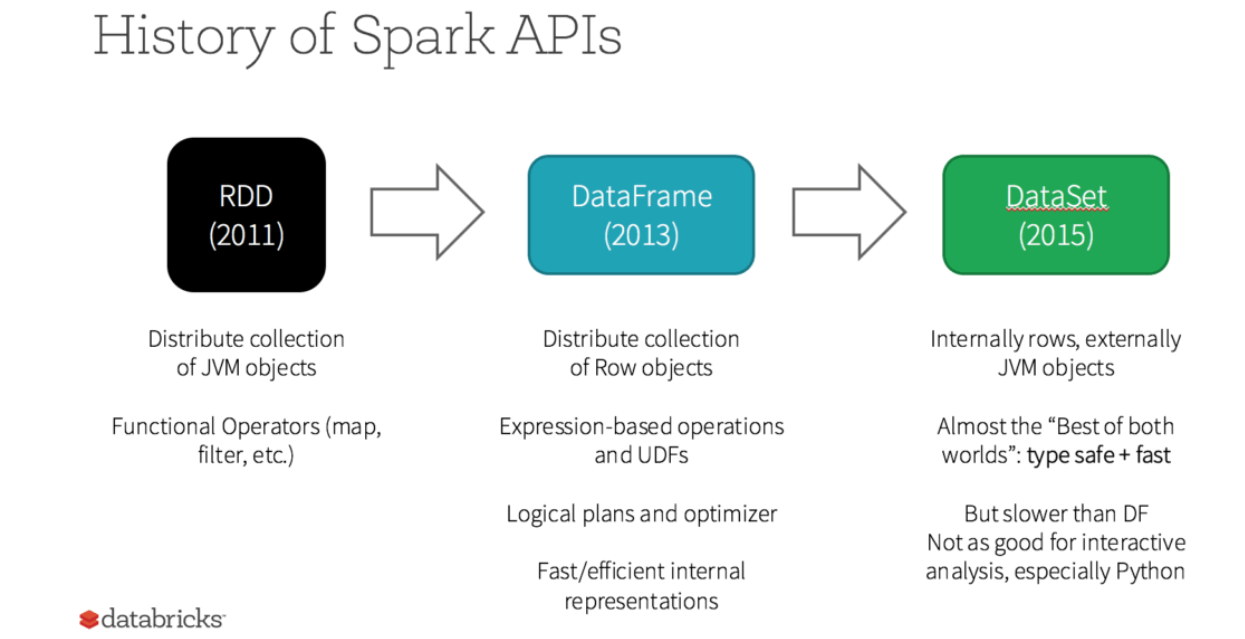


**Resilient Distributed Datasets (RDD)**

Resilient Distributed Datasets (RDD) is a fundamental data structure of Spark. It is an immutable distributed collection of objects. Each dataset in RDD is divided into logical partitions, which may be computed on different nodes of the cluster. RDDs are fundamental for Spark's fault-tolerance and distributed processing capabilities. They can contain any type of Python, Java, or Scala objects, including user-defined classes.

**Key Characteristics of RDD:**

> **Immutable:** RDDs are read-only. You cannot modify an existing RDD; instead, you create new RDDs by applying transformations to existing ones.

> **Distributed:**  Data is split across multiple nodes (partitions).

> **Lazy Evaluation:**  Transformations are not executed until an action is called.

> **Fault Tolerant:**  Can recover from failures using lineage (re-computation).

> **In-Memory Computation:**  Can cache RDDs in memory for faster access.

> **Type-safe(In Scala or Java RDDs):**  Provide compile-time type safety.





**How to Create an RDD in PySpark**

There are two ways to create RDDs − parallelizing an existing collection in your driver program, or referencing a dataset in an external storage system, such as a shared file system, HDFS, HBase, etc.









In [ ]:
!pip install pyspark findspark

In [ ]:
import findspark
findspark.init()

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("PysparkPractice").getOrCreate()

In [ ]:
#From a Python List:
rdd1 = spark.sparkContext.parallelize([1, 2, 3, 4, 5, 6, 7, 8])
rdd1.collect()

[1, 2, 3, 4, 5, 6, 7, 8]

In [ ]:
#From a Text File:
rdd2 = spark.sparkContext.textFile("/content/sample_data/anscombe.json")
rdd2.collect()

['[',
 '  {"Series":"I", "X":10.0, "Y":8.04},',
 '  {"Series":"I", "X":8.0, "Y":6.95},',
 '  {"Series":"I", "X":13.0, "Y":7.58},',
 '  {"Series":"I", "X":9.0, "Y":8.81},',
 '  {"Series":"I", "X":11.0, "Y":8.33},',
 '  {"Series":"I", "X":14.0, "Y":9.96},',
 '  {"Series":"I", "X":6.0, "Y":7.24},',
 '  {"Series":"I", "X":4.0, "Y":4.26},',
 '  {"Series":"I", "X":12.0, "Y":10.84},',
 '  {"Series":"I", "X":7.0, "Y":4.81},',
 '  {"Series":"I", "X":5.0, "Y":5.68},',
 '',
 '  {"Series":"II", "X":10.0, "Y":9.14},',
 '  {"Series":"II", "X":8.0, "Y":8.14},',
 '  {"Series":"II", "X":13.0, "Y":8.74},',
 '  {"Series":"II", "X":9.0, "Y":8.77},',
 '  {"Series":"II", "X":11.0, "Y":9.26},',
 '  {"Series":"II", "X":14.0, "Y":8.10},',
 '  {"Series":"II", "X":6.0, "Y":6.13},',
 '  {"Series":"II", "X":4.0, "Y":3.10},',
 '  {"Series":"II", "X":12.0, "Y":9.13},',
 '  {"Series":"II", "X":7.0, "Y":7.26},',
 '  {"Series":"II", "X":5.0, "Y":4.74},',
 '',
 '  {"Series":"III", "X":10.0, "Y":7.46},',
 '  {"Series":"I

**Creating DataFrames in PySpark**

In [ ]:
# Creating a DataFrame by defining schema
from pyspark.sql.types import StructType, StructField, StringType, IntegerType

schema = StructType([StructField("name",StringType(),True),\
                     StructField("age",IntegerType(),True)])

data = [("Ram",35),("Shyam",30),("Mohan",32),("Rohan",26)]

df1= spark.createDataFrame(data=data,schema=schema)
df1.show()


+-----+---+
| name|age|
+-----+---+
|  Ram| 35|
|Shyam| 30|
|Mohan| 32|
|Rohan| 26|
+-----+---+



In [ ]:
# Creating dataframe by reading a file and inferring the schema from that file
df2 = spark.read.csv("/content/drive/MyDrive/data.csv", inferSchema=True, header=True)
df2.show()

+---------+---------+--------------------+--------+--------------+---------+----------+--------------+
|InvoiceNo|StockCode|         Description|Quantity|   InvoiceDate|UnitPrice|CustomerID|       Country|
+---------+---------+--------------------+--------+--------------+---------+----------+--------------+
|   536365|   85123A|WHITE HANGING HEA...|       6|12/1/2010 8:26|     2.55|     17850|United Kingdom|
|   536365|    71053| WHITE METAL LANTERN|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|
|   536365|   84406B|CREAM CUPID HEART...|       8|12/1/2010 8:26|     2.75|     17850|United Kingdom|
|   536365|   84029G|KNITTED UNION FLA...|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|
|   536365|   84029E|RED WOOLLY HOTTIE...|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|
|   536365|    22752|SET 7 BABUSHKA NE...|       2|12/1/2010 8:26|     7.65|     17850|United Kingdom|
|   536365|    21730|GLASS STAR FROSTE...|       6|12/1/2010 8:26|     4.

In [ ]:
# The field names are taken from the header row of CSV and schema is also inferred from the file
df2.printSchema()

root
 |-- InvoiceNo: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: string (nullable = true)
 |-- UnitPrice: double (nullable = true)
 |-- CustomerID: integer (nullable = true)
 |-- Country: string (nullable = true)



In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, DoubleType, TimestampType

# Start Spark session
spark = SparkSession.builder.appName("CustomSchemaRead").getOrCreate()

# Define custom schema
custom_schema = StructType([
    StructField("InvoiceNo", StringType(), True),
    StructField("StockCode", StringType(), True),
    StructField("Description", StringType(), True),
    StructField("Quantity", IntegerType(), True),
    StructField("InvoiceDate", TimestampType(), True),  # Use TimestampType for date & time
    StructField("UnitPrice", DoubleType(), True),
    StructField("CustomerID", StringType(), True),       # StringType to safely handle missing values
    StructField("Country", StringType(), True)
])

# Read CSV with the custom schema
df = spark.read.options(
    header=True,
    timestampFormat="M/d/yyyy H:mm"   # adjust format if needed
).schema(custom_schema).csv("/content/drive/MyDrive/data.csv")

# Show schema and data
df.printSchema()
df.show(5, truncate=False)


root
 |-- InvoiceNo: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: timestamp (nullable = true)
 |-- UnitPrice: double (nullable = true)
 |-- CustomerID: string (nullable = true)
 |-- Country: string (nullable = true)

+---------+---------+-----------------------------------+--------+-------------------+---------+----------+--------------+
|InvoiceNo|StockCode|Description                        |Quantity|InvoiceDate        |UnitPrice|CustomerID|Country       |
+---------+---------+-----------------------------------+--------+-------------------+---------+----------+--------------+
|536365   |85123A   |WHITE HANGING HEART T-LIGHT HOLDER |6       |2010-12-01 08:26:00|2.55     |17850     |United Kingdom|
|536365   |71053    |WHITE METAL LANTERN                |6       |2010-12-01 08:26:00|3.39     |17850     |United Kingdom|
|536365   |84406B   |CREAM CUPID HEARTS COAT 

In [ ]:
# When we don't read the header and don't specify the schema
df3 = spark.read\
.option("header", "false")\
.csv("/content/drive/MyDrive/data.csv")

df3.show()

+---------+---------+--------------------+--------+--------------+---------+----------+--------------+
|      _c0|      _c1|                 _c2|     _c3|           _c4|      _c5|       _c6|           _c7|
+---------+---------+--------------------+--------+--------------+---------+----------+--------------+
|InvoiceNo|StockCode|         Description|Quantity|   InvoiceDate|UnitPrice|CustomerID|       Country|
|   536365|   85123A|WHITE HANGING HEA...|       6|12/1/2010 8:26|     2.55|     17850|United Kingdom|
|   536365|    71053| WHITE METAL LANTERN|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|
|   536365|   84406B|CREAM CUPID HEART...|       8|12/1/2010 8:26|     2.75|     17850|United Kingdom|
|   536365|   84029G|KNITTED UNION FLA...|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|
|   536365|   84029E|RED WOOLLY HOTTIE...|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|
|   536365|    22752|SET 7 BABUSHKA NE...|       2|12/1/2010 8:26|     7.

In [ ]:
# All the fields are considered to be string and the field names are defined by Spark
df3.schema

StructType([StructField('_c0', StringType(), True), StructField('_c1', StringType(), True), StructField('_c2', StringType(), True), StructField('_c3', StringType(), True), StructField('_c4', StringType(), True), StructField('_c5', StringType(), True), StructField('_c6', StringType(), True), StructField('_c7', StringType(), True)])

**Handling Bad Records**

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, IntegerType, StringType

# Initialize SparkSession (assuming this is already done in your script)
spark = SparkSession.builder \
    .appName("SparkBadRecordsExample") \
    .getOrCreate()

# --- Define the base schema WITHOUT the _corrupt_record column ---
# This schema is for 'good' data records
base_schema = StructType([
    StructField("id", IntegerType(), True),
    StructField("name", StringType(), True),
    StructField("age", IntegerType(), True),
    StructField("city", StringType(), True)
])

# --- Define the schema for PERMISSIVE mode (includes _corrupt_record) ---
# This is created by extending the base_schema
permissive_schema = base_schema.add("_corrupt_record", StringType(), True)

# Create a dummy CSV file (ensure it's at /content/drive/MyDrive/DataEngineering_Training/Data/data.csv)
# If you run this in Colab, ensure you've mounted your Google Drive first.
csv_file_path = "/content/drive/MyDrive/DataEngineering_Training/Data/data.csv"
import os
os.makedirs(os.path.dirname(csv_file_path), exist_ok=True) # Ensure directory exists

with open(csv_file_path, "w") as f:
    f.write("id,name,age,city\n")
    f.write("1,Alice,30,New York\n")
    f.write("2,Bob,25,London\n")
    f.write("3,Charlie,abc,Paris\n") # Malformed age
    f.write("4,David,,Berlin\n") # Missing age
    f.write("5,Eve,40,\n") # Missing city
    f.write("malformed_record_here\n") # Completely malformed row
    f.write("6,Frank,35,Tokyo\n")

**PERMISSIVE (Default Mode):**

When it encounters a corrupted record, it inserts null into fields that couldn't be parsed correctly.
If you define a schema that includes a StringType field named _corrupt_record (or whatever you specify with columnNameOfCorruptRecord), Spark will place the malformed string of the bad record into this column. This allows you to inspect and process the bad records separately.
Records with fewer or more tokens than the schema are generally not considered "corrupted" in this mode for CSV. Missing fields get null, and extra fields are ignored.

In [ ]:
print("--- Using PERMISSIVE Mode ---")
df_permissive = spark.read \
    .option("header", "true") \
    .option("mode", "PERMISSIVE") \
    .option("columnNameOfCorruptRecord", "_corrupt_record") \
    .schema(permissive_schema) \
    .csv(csv_file_path)

df_permissive.show()

--- Using PERMISSIVE Mode ---
+----+-------+----+--------+--------------------+
|  id|   name| age|    city|     _corrupt_record|
+----+-------+----+--------+--------------------+
|   1|  Alice|  30|New York|                NULL|
|   2|    Bob|  25|  London|                NULL|
|   3|Charlie|NULL|   Paris| 3,Charlie,abc,Paris|
|   4|  David|NULL|  Berlin|                NULL|
|   5|    Eve|  40|    NULL|                NULL|
|NULL|   NULL|NULL|    NULL|malformed_record_...|
|   6|  Frank|  35|   Tokyo|                NULL|
+----+-------+----+--------+--------------------+



**DROPMALFORMED:**

Ignores (drops) the entire corrupted record. Only successfully parsed records are loaded into the DataFrame.
Use this mode when you only want to work with clean data and don't need to analyze the bad records.

In [ ]:
print("\n--- Using DROPMALFORMED Mode ---")
# Read the CSV in DROPMALFORMED mode
# IMPORTANT: Use the base_schema here, which does NOT contain _corrupt_record
df_dropmalformed = spark.read \
    .option("header", "true") \
    .option("mode", "DROPMALFORMED") \
    .schema(base_schema) \
    .csv(csv_file_path)

df_dropmalformed.show()


--- Using DROPMALFORMED Mode ---
+---+-----+----+--------+---------------+
| id| name| age|    city|_corrupt_record|
+---+-----+----+--------+---------------+
|  1|Alice|  30|New York|           NULL|
|  2|  Bob|  25|  London|           NULL|
|  4|David|NULL|  Berlin|           NULL|
|  5|  Eve|  40|    NULL|           NULL|
|  6|Frank|  35|   Tokyo|           NULL|
+---+-----+----+--------+---------------+



**FAILFAST:**

Throws an exception immediately if it encounters any corrupted record.
Use this mode when data quality is critical, and you want to halt the processing if any bad records are found.

In [ ]:
print("\n--- Using FAILFAST Mode ---")
try:
    df_failfast = spark.read \
        .option("header", "true") \
        .option("mode", "FAILFAST") \
        .schema(base_schema) \
        .csv(csv_file_path)
    df_failfast.show()
except Exception as e:
    print(f"Error in FAILFAST mode: {e}")


--- Using FAILFAST Mode ---
Error in FAILFAST mode: An error occurred while calling o109.showString.
: org.apache.spark.SparkException: Job aborted due to stage failure: Task 0 in stage 4.0 failed 1 times, most recent failure: Lost task 0.0 in stage 4.0 (TID 5) (52d4abb31fa3 executor driver): org.apache.spark.SparkException: [MALFORMED_RECORD_IN_PARSING.WITHOUT_SUGGESTION] Malformed records are detected in record parsing: [3,Charlie,null,Paris,3,Charlie,abc,Paris].
Parse Mode: FAILFAST. To process malformed records as null result, try setting the option 'mode' as 'PERMISSIVE'. 
	at org.apache.spark.sql.errors.QueryExecutionErrors$.malformedRecordsDetectedInRecordParsingError(QueryExecutionErrors.scala:1610)
	at org.apache.spark.sql.catalyst.util.FailureSafeParser.parse(FailureSafeParser.scala:79)
	at org.apache.spark.sql.catalyst.csv.UnivocityParser$.$anonfun$parseIterator$2(UnivocityParser.scala:456)
	at scala.collection.Iterator$$anon$11.nextCur(Iterator.scala:486)
	at scala.collect

# Lazy Evaluation in Spark

In Apache Spark, lazy evaluation means **transformations** are not executed immediately when they are defined, but are instead deferred until an **action** is called. This approach optimizes performance by building a logical plan of transformations(**Lineage/DAG**) and only executing them when the final result is needed, reducing unnecessary computations and resource usage.

**Operations in RDD**

RDD supports two types of operations:


1.   Transformations
2.   Actions

**Transformations**

Transformations are lazy operations that define a new RDD from an existing one. They do not execute immediately but are computed when an action is called.

Some common transformations are: map, flatMap, filter, distinct, union, intersection, join, groupByKey, reduceByKey, sortByKey.

**Actions**

Actions are the operations that trigger the execution of RDD transformations. They return values to driver program or output data.
For example: collect, count, take,	first, reduce, foreach, saveAsTextFile.


# Fault Tolerance (RDD Lineage)

Fault tolerance is the ability of Spark to recover lost data partitions and recompute results after a node failure. This is achieved through RDD lineage. Lineage is the sequence of transformations that created an RDD from its original data source. In case of a node failure, Spark recomputes lost data using lineage information.

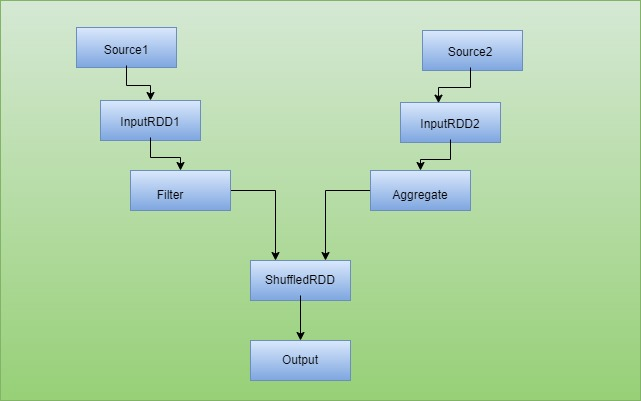

# Narrow and Wide Transformation

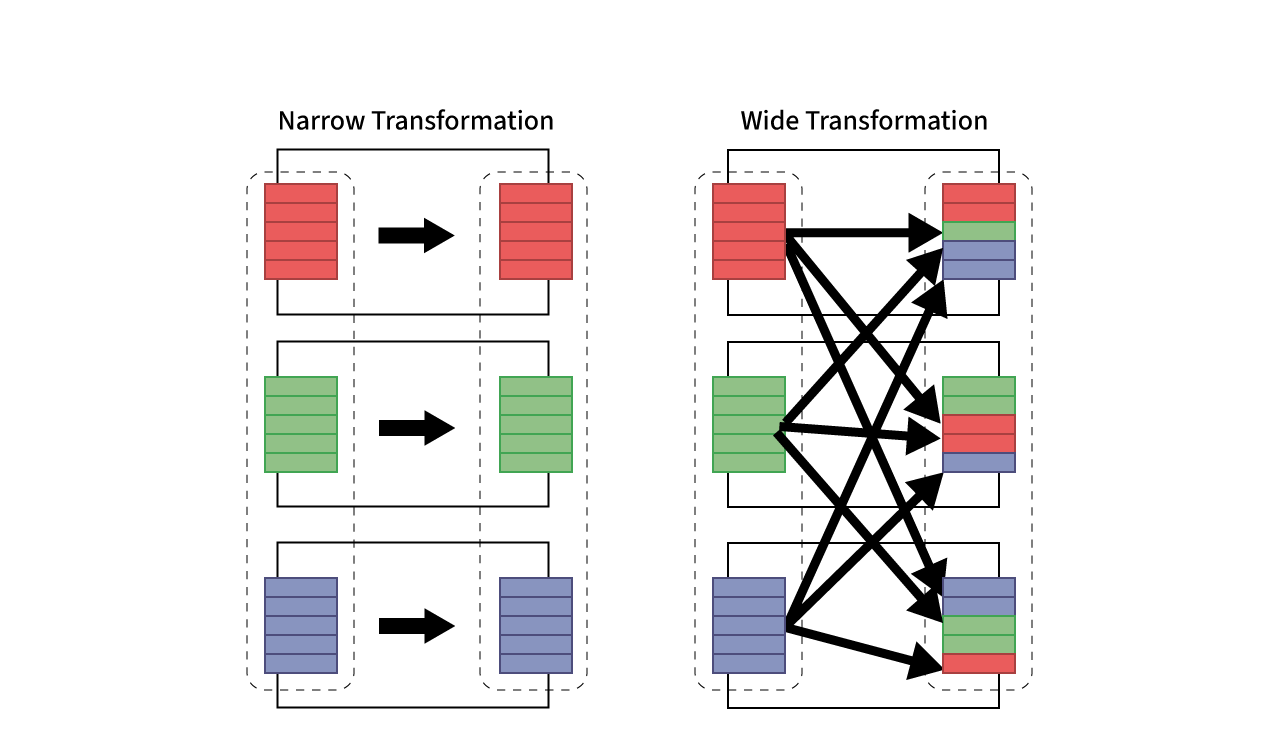


**Narrow Transformation**

A transformation where each partition of the parent RDD is used by at most one partition of the child RDD. This means a child partition only processes data from a single corresponding parent partition. Since each child partition has a specific parent partition to access, there's no need to shuffle data across the network. Shuffling refers to the movement of data between different worker nodes in the Spark cluster. E.g., map, filter etc.

**Wide Transformation**

Wide transformation describes a relationship between RDDs where a child RDD's partitions depend on data from multiple partitions of the parent RDD. Wide dependencies often involve shuffling, which can be a bottleneck. Shuffling data across the network takes time and resources, impacting the overall performance of your Spark application. E.g., GroupByKey, Join, ReduceByKey etc.




In [ ]:
def mul(x):
  return x*2
print(mul(3))

sq = lambda x : x*2
print(sq(3))

6
6


In [ ]:
#Lazy evaluation
rdd3 = rdd1.map(lambda x: x*2)
rdd4 = rdd3.filter(lambda x: x >= 10)
rdd5 = rdd3.filter(lambda x: x <= 10)
rdd6 = rdd4.union(rdd5)
rdd7 = rdd4.intersection(rdd5)
# RDD.collect() is an Action
rdd7.collect()


[10]

In [ ]:
df1 = df.map(lambda x: x*2)
df2 = df.groupBy(lambda x: x >= 10)
df3 = df.filter(lambda x: x <= 10)
df3 = df3.union(rdd5)
df3 = df3.intersection(rdd5)
# RDD.collect() is an Action
df3.collect()
df2.show()

In [ ]:
# Action example
rdd6.count()

9

In [ ]:
rdd3.take(5)

[2, 4, 6, 8, 10]

In [ ]:
rdd3.first()

2

In [ ]:
# Wide transformation example
print(rdd3.reduce(lambda x,y: x+y))

72


# GroupBy, groupByKey, reduceByKey, aggregateByKey

All of these are grouping operations, but differ in terms of performance, when to use them, and underlying mechanics.

**groupBy():**

This operation is used with both RDDs and DataFrames. It groups data by a function(RDD) or column(s) (DataFrame). It becomes more efficient when combined with aggregation. It is used in cases where you want to group the data and then aggregate.

With RDDs it can be expensivefor large datasets.
With dataframes, groupBy() works efficiently with Catalyst Optimizer, and it is the preferred way for grouped analysis.

In [ ]:
rdd = spark.sparkContext.parallelize(["apple","banana","apricot","blueberry"])
grouped = rdd.groupBy(lambda x:x[0])
print({k: list(v) for k,v in grouped.collect()})

{'b': ['banana', 'blueberry'], 'a': ['apple', 'apricot']}


In [ ]:
df = spark.createDataFrame([("a",1),("b",2),("a",3)],["key","value"])
df.groupBy("key").count().show()

+---+-----+
|key|count|
+---+-----+
|  a|    2|
|  b|    1|
+---+-----+



**groupByKey():**

It works with RDDs containing key-value pairs. Given an RDD with key-value pairs, it returns an RDD with the keys and an iterable collection of values for each key.

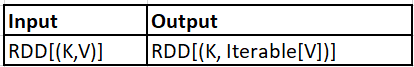

It shuffles all values across the network to group the values for their respective keys together. Hence, it is expensive. This operation can be used in case you only need to group the data and not perform any aggregation.

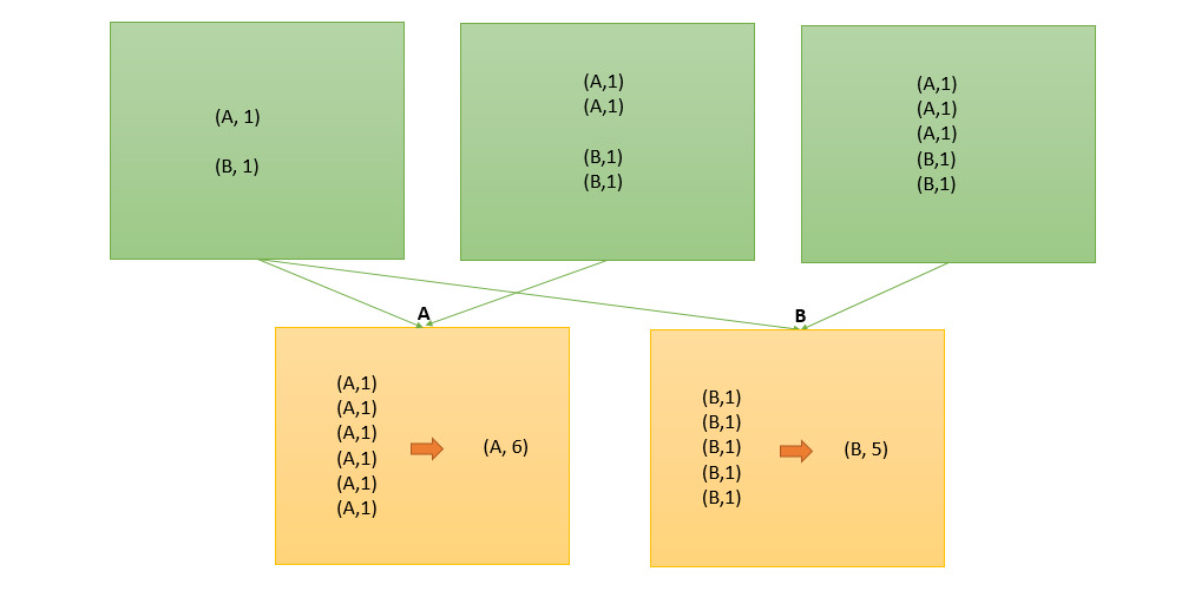

In [ ]:
rdd = spark.sparkContext.parallelize([("a",1),("b",2),("a",3)])
grouped = rdd.groupByKey()
print([(k,list(v)) for k,v in grouped.collect()])

[('b', [2]), ('a', [1, 3])]


**reduceByKey()**

This operation also works on key-value pairs in RDD, but it is more efficient than groupByKey(). This is because it combines values before shuffling.

In [ ]:
rdd = spark.sparkContext.parallelize([("a",1),("b",2),("a",3)])
rdd.reduceByKey(lambda x,y: x+y).collect()


[('b', 2), ('a', 4)]

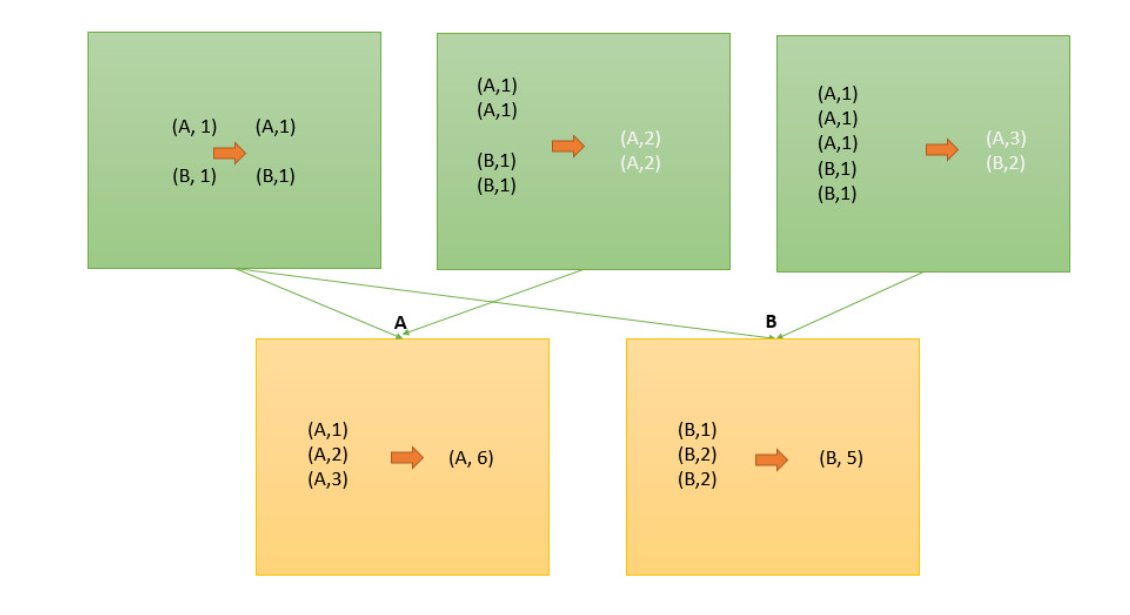

**aggregateByKey()**

It is a powerful and flexible agggregation function in Spark used on key-value RDDs. It is more advanced than reduceByKey() and allows different logic for combining values within and across partitions, making it great for customized aggregations.
It is especially useful when you want more control over how values are aggregated, maintain intermediate state (e.g., compute average), or minimize shuffles by doing heavy work within partitions.

Syntax:
  rdd.aggregateByKey(zeroValue, seqFunc, combFunc)

**zeroValue :** The initial value for the aggregation (like an accumulator).

**seqFunc :** Function to combine values within a partition.

**combFunc :** Function to merge results across partitions.

In [ ]:
rdd = spark.sparkContext.parallelize([("a",1),("b",2),("a",3),("b",4)])
# (sum, count) as zero value
zero_val = (0, 0)

# Within partition
seq = lambda acc, value: (acc[0] + value, acc[1] + 1)

# Across partitions
comb = lambda acc1, acc2: (acc1[0] + acc2[0], acc1[1] + acc2[1])

aggregated = rdd.aggregateByKey(zero_val,seq, comb)

average = aggregated.mapValues(lambda x: x[0] / x[1])
print(average.collect())

[('b', 3.0), ('a', 2.0)]


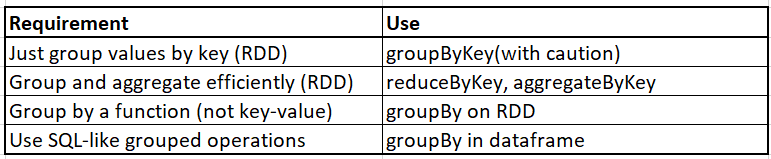

# Map vs FlatMap

Both map() and flatMap() are transformations used to process data in RDDs or DataFrames. However, they differ in how they handle the output of the function you apply.

**map():** Applies a function to each element and returns a new RDD with one output element per input element.

**flatMap():** Similar to map(), but flattens the results. It returns zero or more output elements for each input element.

In [ ]:
# map example
rdd = spark.sparkContext.parallelize(["apple", "banana"])
mapped = rdd.map(lambda x: list(x))
print(mapped.collect())

[['a', 'p', 'p', 'l', 'e'], ['b', 'a', 'n', 'a', 'n', 'a']]


In [ ]:
# flatMap example
rdd = spark.sparkContext.parallelize(["apple", "banana"])
flat_mapped = rdd.flatMap(lambda x: list(x))
print(flat_mapped.collect())

['a', 'p', 'p', 'l', 'e', 'b', 'a', 'n', 'a', 'n', 'a']


# Data Skewness

Data skewness in the context of distributed computing (like Spark) refers to an uneven distribution of data across partitions or keys, which leads to performance bottlenecks due to some tasks taking much longer than others.

**Types of Skewness**
1. Key Skew (Join Skew)

Happens when a few keys have a disproportionately large number of records. It is common in joins and aggregations.
Example: If 90% of your sales records are for one product ID, and you join on product_id, the partition containing that key will be huge.

2. Partition Skew

When data is not evenly distributed across partitions.In this case some tasks process large partitions while others finish quickly.

**Issues with Data Skewness**


* Skewness causes straggler tasks that delay job completion.

* Leads to out-of-memory errors or shuffle overloads.

* Wastes resources by underutilizing part of the cluster.

**Detecting Skewness**

* Using Spark UI:  Spark UI → Stages → Task time
* Data Analysis: Counting records per key or partition.



# Partitioning and Bucketing

In Spark, partitioning and bucketing are data organization techniques used to optimize query performance and reduce shuffle operations. Partitioning divides data into smaller, more manageable parts based on a column's values, enabling Spark to skip reading unnecessary data during filtering. Bucketing further subdivides data within partitions based on a hash function, primarily to optimize join operations by pre-sorting data within buckets.

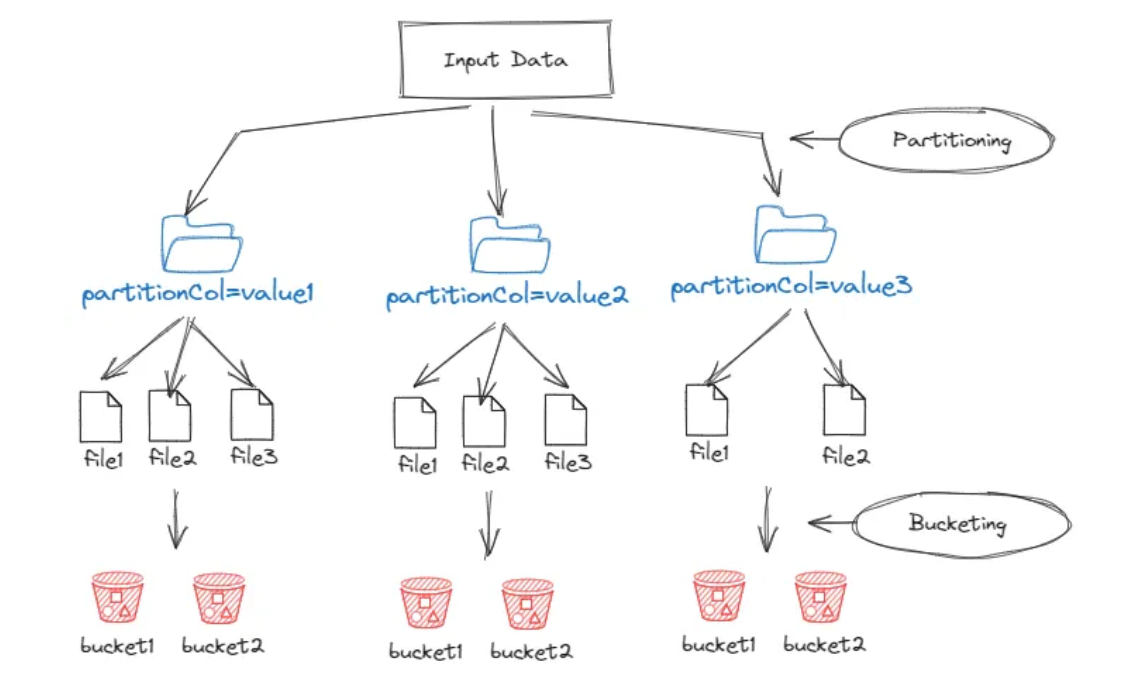



**Partitioning**

Partitioning refers to dividing data into partitions based on a column's values, creating directories in the file system corresponding to those values. It helps to reduce the amount of data Spark needs to read by skipping partitions that don't match a filter condition. Partitioning is useful when you frequently filter on a column with low cardinality (few distinct values).

Example: If you're querying sales data by region, you might partition the data by region, so Spark can quickly skip partitions that don't belong to the region in the query.

NOTE: If a column with high cardinality is chosen to partition the data, it will create a large number of small partitions resulting in overhead.



In [ ]:
from pyspark.sql import SparkSession
from datetime import date

# Create a SparkSession
spark = SparkSession.builder.appName("partitionByExample").getOrCreate()

# Sample sales data
data = [
    (date(2024, 1, 1), "Laptop", 1500),
    (date(2024, 1, 1), "Tablet", 500),
    (date(2024, 1, 2), "Laptop", 1600),
    (date(2024, 1, 2), "Monitor", 300),
    (date(2024, 1, 3), "Laptop", 1700),
    (date(2024, 1, 3), "Mouse", 25),
]

# Create a DataFrame
columns = ["date", "product", "sales"]
df = spark.createDataFrame(data, columns)

# Write the DataFrame to a partitioned Parquet file
output_path = "/content/drive/MyDrive/DataEngineering_Training/Data/PartitionBy"
df.write.partitionBy("date").mode("overwrite").parquet(output_path)


# Stop the SparkSession
spark.stop()


**Bucketing**

Bucketing is a technique used in Spark for optimizing data storage and querying performance, especially when dealing with large datasets. It involves dividing data into a fixed number of buckets and storing each bucket as a separate file.

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("BucketingExample") \
    .config("spark.sql.shuffle.partitions", 4) \
    .enableHiveSupport() \
    .getOrCreate()

# Create a sample purchases dataset
purchases_df = spark.createDataFrame([
    (1, 100), (2, 200), (1, 300),
    (3, 400), (4, 500), (2, 600)
], ["user_id", "amount"])

output_path_purchase = "/content/drive/MyDrive/DataEngineering_Training/Data/Buckets"
# Save purchases with bucketing
purchases_df.write \
    .bucketBy(4, "user_id") \
    .sortBy("user_id") \
    .mode("overwrite") \
    .parquet(output_path_purchase)


AnalysisException: 'save' does not support bucketBy right now.

# Salting

Suppose you have a dataset with a key (field on which partition/join takes place), and some keys are highly skewed, meaning they appear much more frequently than others. When performing operations like joins or aggregations, Spark might assign all data with the same key to a single partition, causing that partition to become overloaded while others remain underutilized. This can lead to performance bottlenecks and slow down Spark jobs.

Salting in Apache Spark is a technique used to address such data skew issues. It  involves artificially increasing the number of distinct keys in a dataset by appending a random or unique identifier to each key. This random identifier, known as a “salt,” helps distribute the data more evenly across partitions, reducing the likelihood of data skew.  

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, lit, concat, rand, floor

spark = SparkSession.builder.appName("SaltingExample").getOrCreate()

# Large skewed DataFrame
df_large = spark.createDataFrame([
    ("A", 1), ("A", 2), ("A", 3),
    ("B", 4), ("B", 5),
    ("C", 6)
], ["id", "value"])

# Small lookup DataFrame
df_small = spark.createDataFrame([
    ("A", "Alpha"),
    ("B", "Beta"),
    ("C", "Gamma")
], ["id", "name"])

# Set number of salts
N = 5

# Add random salt to df_large
df_large_salted = df_large.withColumn("salt", floor(rand() * N).cast("int"))
df_large_salted = df_large_salted.withColumn("id_salt", concat(col("id"), lit("_"), col("salt")))

# For df_small, duplicate each row N times with static salts (no explode)
# Create a salted version for join using crossJoin with a salt lookup table
salt_values = spark.createDataFrame([(i,) for i in range(N)], ["salt"])

df_small_salted = df_small.crossJoin(salt_values)
# df_small_salted.show()
df_small_salted = df_small_salted.withColumn("id_salt", concat(col("id"), lit("_"), col("salt")))

joined_df = df_large_salted.join(df_small_salted, on="id_salt", how="inner")
joined_df.show()



+-------+---+-----+----+---+-----+----+
|id_salt| id|value|salt| id| name|salt|
+-------+---+-----+----+---+-----+----+
|    A_1|  A|    1|   1|  A|Alpha|   1|
|    A_3|  A|    3|   3|  A|Alpha|   3|
|    A_4|  A|    2|   4|  A|Alpha|   4|
|    B_0|  B|    4|   0|  B| Beta|   0|
|    B_2|  B|    5|   2|  B| Beta|   2|
|    C_4|  C|    6|   4|  C|Gamma|   4|
+-------+---+-----+----+---+-----+----+



# Dynamic Partition Pruning

Dynamic partition pruning (DPP) in Apache Spark is a query optimization technique that improves performance by selectively scanning only the necessary partitions of a partitioned table during query execution. It works by analyzing the query predicates and intelligently determining which partitions need to be scanned based on the filter conditions. This eliminates the need to scan all partitions, thus minimizing disk reads and improving query efficiency.

In [ ]:
# Parameter for enabling Dynamic Partition Pruning:

spark.conf.set("spark.sql.optimizer.dynamicPartitionPruning.enabled", "true")

In [ ]:
# Partitioned fact table
fact_df.write.partitionBy("region_id").mode("overwrite").parquet("/tmp/fact")

# Dimension table
dim_df = spark.read.parquet("/tmp/dim").filter("region_name = 'South'")

fact = spark.read.parquet("/tmp/fact")
joined = fact.join(dim_df, fact.region_id == dim_df.region_id)
joined.show()


# Repartition and Coalesce

In Apache Spark, **repartition()** is a transformation used to change the number of partitions in a DataFrame or RDD by performing a full shuffle of the data across the cluster. It redistributes all data across the specified number of partitions and ensures even distribution of data across partitions. It can be used to increase or decrease the number of partitions. Repartition helps avoid skew, improve parallelism, or optimize file output.

Since repartition() triggers a full shuffle, it’s expensive and should be used only when needed.

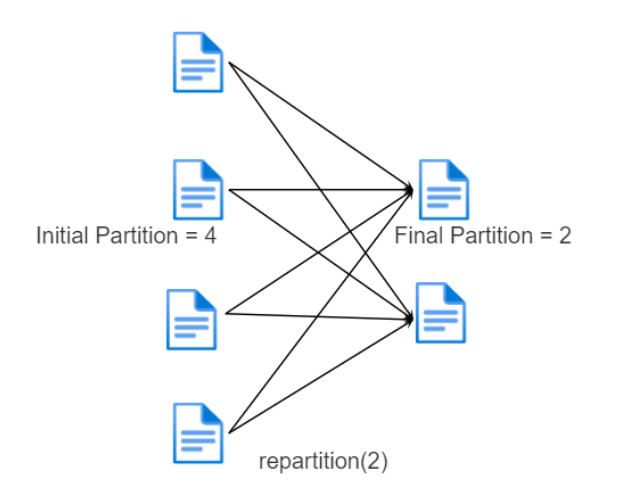




**coalesce()** is a transformation used to reduce the number of partitions without a full shuffle, making it a faster and more efficient option compared to repartition(). It combines adjacent partitions to create fewer partitions.
It cannot be used to increase partitions — only decrease or keep the same.

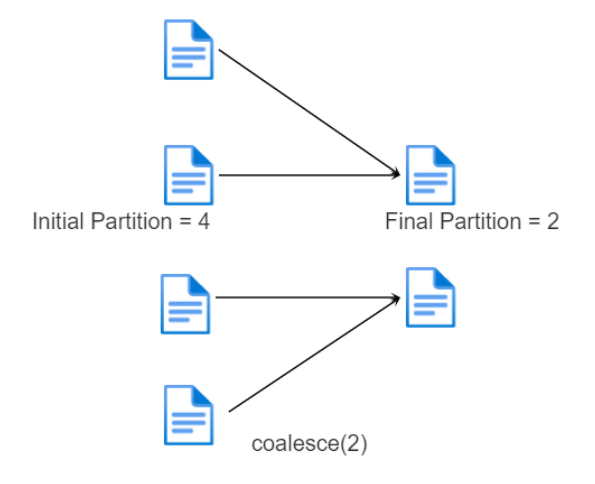

In [ ]:
# Syntax of repartition

num_partitions = 2
df_repartitioned = df.repartition(num_partitions) # based on number of partitions
df_repartitioned = df.repartition("column_name") # based on column

In [ ]:
# Syntax of coalesce

df_small = df.coalesce(num_partitions)


# Broadcast Variable and Accumulator

**Broadcast Variable**

Broadcast variable is a shared, read-only variable cached on each node of the cluster. It allows for efficient distribution of datasets or objects needed across multiple tasks, minimizing network overhead. Instead of sending the data with every task, it is sent once from the driver to each executor, and tasks can then access it locally.

**Creating Broadcast Variable**
    spark.sparkContext.broadcast(variable)

**Accessing the value**
    broadcast_variable.value

In [ ]:
from pyspark.sql.functions import udf,col
from pyspark.sql.types import StringType

lookup_table = {"A":"value A", "B":"value B"}
broadcast_lookup = spark.sparkContext.broadcast(lookup_table)

data = [("A",),("B",),("C",)]
df = spark.createDataFrame(data, ["key"])

def get_value(key):
    return broadcast_lookup.value.get(key,"Not found")

get_value_udf = udf(get_value, StringType())
df_with_values = df.withColumn("value", get_value_udf(col("key")))
df_with_values.show()

+---+---------+
|key|    value|
+---+---------+
|  A|  value A|
|  B|  value B|
|  C|Not found|
+---+---------+



**Accumulator**

An accumulator is a special type of shared variable used to accumulate values across multiple tasks in a parallel and fault-tolerant manner. They are primarily employed for aggregating information such as counters or sums during distributed computations.


In [ ]:
from pyspark.sql import Row

# Create an accumulator with an initial value of 0
even_count = spark.sparkContext.accumulator(0)

# Define a function to check if a number is even and update the accumulator
def count_even(num):
  global even_count
  if num % 2 == 0:
    even_count+=1

data = [(1,),(2,),(3,),(4,),(5,),(6,)]
columns = ["numbers"]

df = spark.createDataFrame(data, columns)

df.rdd.foreach(lambda x: count_even(x[0]))

print("Number of even numbers:", even_count.value)


Number of even numbers: 3


**Limitations of accumulators**

* Accumulators are updated only when an action is triggered.
* Task retries can cause accumulators to increment multiple times, leading to inflated values.


**Accumulator vs Broadcast Variable**

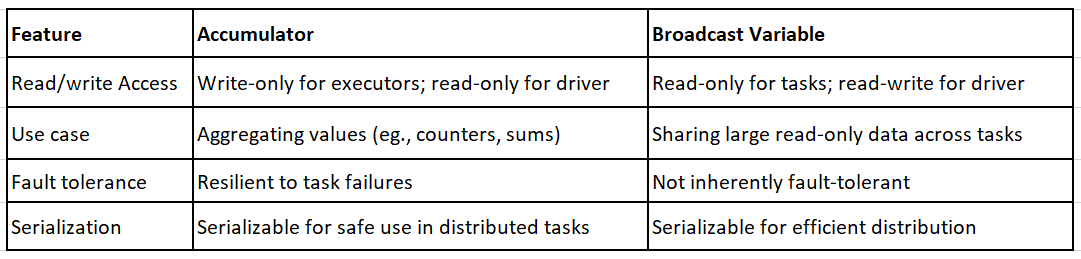

# Broadcast Join / Broadcast Hash Join

A broadcast join is a specific type of join optimization used in distributed computing frameworks like Apache Spark, and it’s designed to improve the efficiency of joining. It works in the case where one of the dataframes is large and the other one is small enough to fit in the memory of each worker node.

In a traditional join, each node in the cluster needs to shuffle and exchange data related to the join key across the network. This can be computationally expensive, especially if the large DataFrame is shuffled.

Instead of shuffling the entire large DataFrame, read-only copies of the small DataFrame (broadcast DataFrame) is broadcasted to all nodes in the cluster. Since the smaller DataFrame is available on each node, the join operation can be performed locally on each node without the need for extensive data movement.
This reduces the amount of network traffic and can significantly improve the performance of the join, especially when the small DataFrame fits in the memory of each node.

If the smaller table is below the broadcast threshold(default is **10MB**), Spark will automatically broadcast it. Once the read-only copies of the smaller dataset is available in the memory of all worker nodes in the cluster, hash join is performed between these copies and the partitions of the larger dataframe present in the respective worker nodes.

**NOTE**

A hash join is a join strategy that uses a hash table to efficiently join two datasets, especially when at least one of them fits in memory. Spark builds a hash table on the smaller dataset (typically the right side of the join) using the join key(s). It then scans the larger dataset (left side), and for each row, uses the join key to look up matches in the hash table.

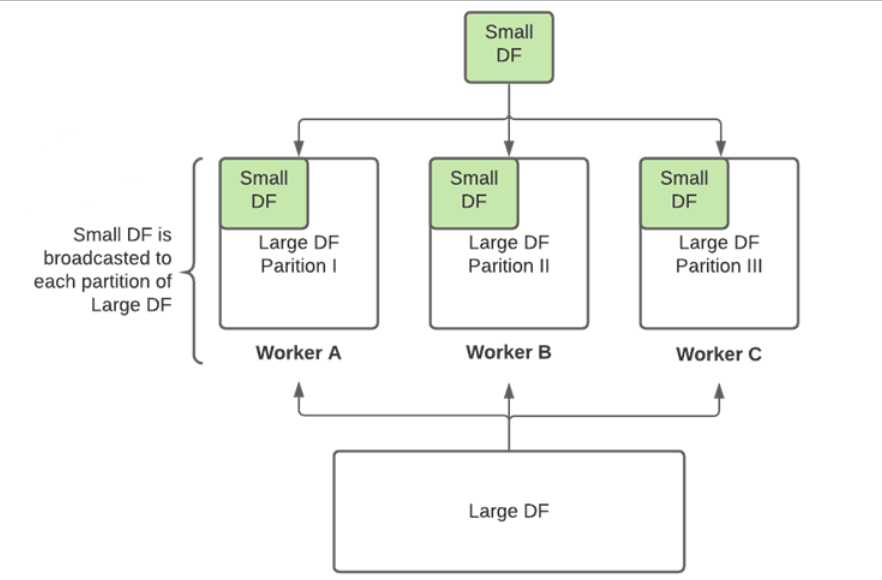

In [ ]:
# Syntax of Broadcast join
from pyspark.sql.functions import broadcast

# small_df is the smaller DataFrame
result = large_df.join(broadcast(small_df), "key")


In [ ]:
# Example to increase broadcast threshold

spark.conf.set("spark.sql.autoBroadcastJoinThreshold", 50 * 1024 * 1024)  # 50 MB


In [ ]:
# To disable the broadcast threshold limit, the threshold can be set to -1

spark.conf.set("spark.sql.autoBroadcastJoinThreshold", -1)

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import broadcast

# Initialize the Spark session
spark = SparkSession.builder.appName("Broadcast Join Example").getOrCreate()

# Create DataFrames from sample data
sales_data = [(1, 101, 2), (2, 102, 1), (3, 103, 3), (4, 101, 1), (5, 104, 4)]
products_data = [(101, "Learn C++", 10), (102, "Mobile: X1", 20), (103, "LCD", 30), (104, "Laptop", 40)]

sales_columns = ["order_id", "product_id", "quantity"]
products_columns = ["product_id", "product_name", "price"]

sales_df = spark.createDataFrame(sales_data, schema=sales_columns)
products_df = spark.createDataFrame(products_data, schema=products_columns)

# Perform broadcast join
result = sales_df.join(broadcast(products_df), sales_df["product_id"] == products_df["product_id"])

# Show the Physical Plan
result.explain()

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- BroadcastHashJoin [product_id#1L], [product_id#6L], Inner, BuildRight, false
   :- Filter isnotnull(product_id#1L)
   :  +- Scan ExistingRDD[order_id#0L,product_id#1L,quantity#2L]
   +- BroadcastExchange HashedRelationBroadcastMode(List(input[0, bigint, false]),false), [plan_id=20]
      +- Filter isnotnull(product_id#6L)
         +- Scan ExistingRDD[product_id#6L,product_name#7,price#8L]




**NOTE:**
* If the small table is actually large, broadcasting it will cause OutOfMemory errors.

* If you're joining on non-equi conditions or complex expressions, broadcast joins won't be used.


#Sort Merge Join

The Sort Merge Join is the default join selection strategy when both sides of the join are large and join keys are sortable. It goes through the following three phases-
1. Shuffle
2. Sort
3. Merge

The data from both the dataframes are first shuffledacross all the partitions on the worker nodes so that the data having a particular value of the join key column can be stored in the same partition for respective dataframes, and the resultant partitions of both the dataframes can be stored on the same worker node.

After the shuffle phase is over, the data in each partition is sorted based on the value of the join key column.

In the merge phase, a partition from the first dataframe is merged with a partition of the second dataframe based on the same value of the join key column in the same working node.





In [ ]:
# Disabling broadcast join
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", -1)

# Create two large DataFrames
df1 = spark.range(0,1_000_000).withColumnRenamed("id", "key1")
df2 = spark.range(500_000,1_500_000).withColumnRenamed("id", "key2")

# Perform a Sort Merge Join
joined_df = df1.join(df2, df1.key1 == df2.key2)

joined_df.explain()

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- SortMergeJoin [key1#33L], [key2#37L], Inner
   :- Sort [key1#33L ASC NULLS FIRST], false, 0
   :  +- Exchange hashpartitioning(key1#33L, 200), ENSURE_REQUIREMENTS, [plan_id=150]
   :     +- Project [id#31L AS key1#33L]
   :        +- Range (0, 1000000, step=1, splits=2)
   +- Sort [key2#37L ASC NULLS FIRST], false, 0
      +- Exchange hashpartitioning(key2#37L, 200), ENSURE_REQUIREMENTS, [plan_id=151]
         +- Project [id#35L AS key2#37L]
            +- Range (500000, 1500000, step=1, splits=2)




#Shuffle Hash Join

Shuffle Hash Join is a join strategy in Spark where both sides of the join are shuffled across the cluster based on the join keys, and then one side is hashed in memory for fast lookup.

Shuffle hash join goes through the following three phases:
1. Shuffle
2. Hash Table Creation
3. Hash Join

The data in each partition, for both dataframes, need to be shuffled so that all the data, having a particular value of the join key column can be stored in the same partition for the respective dataframes, and the resultant partitions of both dataframes can be stored in the same worker node.

Once the shuffle phase is over, a hash table will be created for each of the partitions of the smaller dataframe.

Once the hash table creation for the smaller dataframe is complete, each hash table will be joined with the respective partition of the larger dataframe in the same working node.

**NOTE:** The Shuffle Hash Join is an expensive operation because it uses both shuffling and hashing, which are individually expensive operations. Also, maintaining a hash table requires memory and computation.

Since it is expensive, shuffle hash join will not be selected as the join strategy by default. It can be used when Sort Merge Jojn operation is disabled as the default strategy and both the dataframes are above the range of the default broadcast threshold.



**How to use Shuffle Hash Join**

In [ ]:
# Forcibly disable the Broadcast Has Join
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", -1)

# Disable the Sort Merge Join as the default join strategy
spark.conf.set("spark.sql.join.preferSortMergeJoin", "false")

# Enable the Shuffle Hash Join
spark.conf.set("spark.sql.join.useHash", "true")

df1 = spark.range(0,1_000_000).withColumnRenamed("id", "key1")
df2 = spark.range(500_000,1_500_000).withColumnRenamed("id", "key2")

# Explicitly pass the join hint as Shuffle Hash for the small dataframe, while joining
joined_df = df1.join(df2.hint("SHUFFLE_HASH"), df1.key1 == df2.key2)

joined_df.explain()

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- ShuffledHashJoin [key1#45L], [key2#49L], Inner, BuildRight
   :- Exchange hashpartitioning(key1#45L, 200), ENSURE_REQUIREMENTS, [plan_id=176]
   :  +- Project [id#43L AS key1#45L]
   :     +- Range (0, 1000000, step=1, splits=2)
   +- Exchange hashpartitioning(key2#49L, 200), ENSURE_REQUIREMENTS, [plan_id=177]
      +- Project [id#47L AS key2#49L]
         +- Range (500000, 1500000, step=1, splits=2)




#Cache and Persist

cache() and persist() are used to store intermediate results of RDDs or DataFrames in memory (or disk) to speed up subsequent actions on the same data. They help avoid recomputing the same data multiple times, which can significantly improve performance.

**Caching:** Caching is a temporary storage level in memory that stores a small piece of information which is frequently used in the majority of tasks.

**Persisting:** It’s a similar approach to caching, but persistence has the capability to store the data in memory as well as on disk. persist() offers more control by allowing you to choose different storage levels.
You can specify levels like:
* MEMORY_ONLY
* DISK_ONLY
* MEMORY_AND_DISK
* MEMORY_ONLY_SER
* MEMORY_AND_DISK_SER
* OFF_HEAP

It is suitable for larger datasets or when you need to optimize for memory usage, fault tolerance, or specific use cases.

In [ ]:
df = spark.read.csv("/content/drive/MyDrive/DataEngineering_Training/Data/data.csv", header=True, inferSchema=True)
df.cache()
df.count()  # Triggers caching


7

In [ ]:
from pyspark import StorageLevel

df.persist(StorageLevel.MEMORY_ONLY)
df.count()


7

# Adaptive Query Execution (AQE)

Adaptive Query Execution (AQE) in Spark is a powerful feature introduced in Spark 3.0 that enables the query planner to dynamically optimize query plans at runtime, using real-time statistics gathered during query execution.
In traditional query execution, Spark relies heavily on static estimates (like cardinality or join selectivity) made during query planning. These estimates can be off, especially with:


*   Skewed data
*   Unreliable or outdated statistics
*   Complex or nested transformations

AQE helps by adjusting the execution plan on the fly once more accurate data is available.

**Key Features of AQE**

1. **Dynamic Join Strategy Selection**
  Spark can switch between:
  * Sort Merge Join(SMJ)
  * Broadcast Hash Join(BHJ)
  * Shuffle Hash Join

  Example: If during execution Spark realizes one side of a join is small enough to be broadcasted, it switches to BHJ, avoiding expensive shuffles.

2. **Dynamic Partition Coalescing**
  * Automatically merges small shuffle partitions at runtime to reduce task overhead.
  * Especially useful for queries with many tiny output files (common in skewed data).

3. **Handling Skewed Joins**
  * Detects data skew and splits skewed partitions into smaller ones.
  * Use different join strategies for skewed vs. non-skewed partitions.




In [ ]:
# How to Enable AQE

spark.conf.set("spark.sql.adaptive.enabled", "true")

# Or

# spark = SparkSession.builder \
#     .appName("Enable AQE") \
#     .config("spark.sql.adaptive.enabled", "true") \
#     .getOrCreate()

spark.conf.get("spark.sql.adaptive.enabled")


'true'